# 1. Project Title

## PCA-Based Forged Signature Detection Using Machine Learning

This notebook extends the earlier linear algebra mini-project into a supervised machine learning workflow.  
The core idea is:

**image data -> PCA -> dimensionality reduction -> classifier -> evaluation**


# 2. Objective

The goal of this machine learning version is to:

- load handwritten signature images from the local dataset,
- preprocess them into numeric vectors,
- apply PCA only after the train/test split to avoid leakage,
- compare multiple classifiers built on PCA features,
- compare PCA-based models with a raw-pixel baseline,
- connect the supervised ML approach with the earlier manual PCA anomaly-detection project.


# 3. Dataset Description

Dataset source: Kaggle Signature Verification Dataset  
Local path used in this project: `extract/`

Folder interpretation:

- numeric folder names such as `001`, `002`, `003` represent **genuine** signatures,
- folders ending in `_forg` represent **forged** signatures.

Experimental design for this mini-project:

- use a balanced subset of **150 genuine** and **150 forged** images,
- if fewer were available, the code would automatically choose the maximum balanced number,
- convert every image to grayscale,
- resize to **32 x 32**,
- normalize to `[0, 1]`,
- flatten to **1024 features**.


# 4. Import Libraries

The next cell imports the libraries needed for image processing, PCA, machine learning, evaluation, and visualization.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["image.cmap"] = "gray"

print("NumPy version        :", np.__version__)
print("Pandas version       :", pd.__version__)
print("Matplotlib available :", plt is not None)


NumPy version        : 2.5.1
Pandas version       : 3.0.5
Matplotlib available : True


Matplotlib is building the font cache; this may take a moment.


# 5. Dataset Loading

To keep the notebook reusable and clean, the project uses three reusable helper functions:

- `load_signature_images()`
- `image_to_vector()`
- `build_dataset()`

The loader recursively identifies genuine and forged folders from the real local dataset.


In [2]:
ABSOLUTE_DATA_DIR = Path("/Users/medepatiramtejareddy/Downloads/maths_sign/extract")

candidate_paths = [
    ABSOLUTE_DATA_DIR,
    Path.cwd() / "extract",
    Path("extract"),
]

DATA_DIR = None
for candidate in candidate_paths:
    if candidate.exists():
        DATA_DIR = candidate.resolve()
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not locate the local dataset directory. Update ABSOLUTE_DATA_DIR if needed."
    )

IMAGE_SIZE = (32, 32)
MAX_PER_CLASS = 150
RANDOM_STATE = 42
TEST_SIZE = 0.20
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}


def load_signature_images(data_dir):
    # Collect genuine and forged image paths from the real folder structure.
    genuine_paths = []
    forged_paths = []

    for folder in sorted(data_dir.iterdir()):
        if not folder.is_dir():
            continue

        image_paths = sorted(
            [
                path
                for path in folder.iterdir()
                if path.suffix.lower() in IMAGE_EXTENSIONS
            ]
        )

        if folder.name.isdigit():
            genuine_paths.extend(image_paths)
        elif folder.name.endswith("_forg"):
            forged_paths.extend(image_paths)

    return genuine_paths, forged_paths


def image_to_vector(path, image_size=IMAGE_SIZE, crop_threshold=245):
    # Crop the signature foreground before resizing so the model focuses on strokes instead of mostly white background.
    image = Image.open(path).convert("L")
    pixel_array = np.array(image)
    foreground_mask = pixel_array < crop_threshold

    if foreground_mask.any():
        ys, xs = np.where(foreground_mask)
        pixel_array = pixel_array[ys.min(): ys.max() + 1, xs.min(): xs.max() + 1]

    image = Image.fromarray(pixel_array)
    image = ImageOps.autocontrast(image)
    image = image.resize(image_size)
    pixel_array = np.array(image, dtype=np.float64) / 255.0
    return pixel_array.reshape(-1)


def build_dataset(data_dir, max_per_class=MAX_PER_CLASS, image_size=IMAGE_SIZE):
    genuine_paths, forged_paths = load_signature_images(data_dir)
    balanced_count = min(len(genuine_paths), len(forged_paths), max_per_class)

    selected_genuine = genuine_paths[:balanced_count]
    selected_forged = forged_paths[:balanced_count]

    X_genuine = np.array([image_to_vector(path, image_size=image_size) for path in selected_genuine])
    X_forged = np.array([image_to_vector(path, image_size=image_size) for path in selected_forged])

    X = np.vstack([X_genuine, X_forged])
    y = np.array([0] * len(X_genuine) + [1] * len(X_forged))
    paths = selected_genuine + selected_forged

    return {
        "X": X,
        "y": y,
        "paths": paths,
        "selected_genuine": selected_genuine,
        "selected_forged": selected_forged,
        "all_genuine": genuine_paths,
        "all_forged": forged_paths,
        "balanced_count": balanced_count,
    }


dataset = build_dataset(DATA_DIR)

print("Dataset directory:", DATA_DIR)
print("Total genuine images available:", len(dataset["all_genuine"]))
print("Total forged images available :", len(dataset["all_forged"]))
print("Balanced subset per class     :", dataset["balanced_count"])


Dataset directory: /Users/medepatiramtejareddy/Downloads/maths_sign/extract
Total genuine images available: 7313
Total forged images available : 7313
Balanced subset per class     : 150


# 6. Dataset Inspection

The next cell prints dataset size, class counts, shapes, and a preview of selected files.  
Label convention used in this notebook:

- `0 = Genuine`
- `1 = Forged`


In [3]:
X = dataset["X"]
y = dataset["y"]
selected_genuine = dataset["selected_genuine"]
selected_forged = dataset["selected_forged"]

class_distribution = pd.Series(y).map({0: "Genuine", 1: "Forged"}).value_counts()

print("Final dataset shape      :", X.shape)
print("Target vector shape      :", y.shape)
print("Original feature size    :", X.shape[1])
print("Class distribution:")
print(class_distribution.to_string())

print("\nFirst 3 genuine files:")
for path in selected_genuine[:3]:
    print(" ", path.relative_to(DATA_DIR).as_posix())

print("\nFirst 3 forged files:")
for path in selected_forged[:3]:
    print(" ", path.relative_to(DATA_DIR).as_posix())


Final dataset shape      : (300, 1024)
Target vector shape      : (300,)
Original feature size    : 1024
Class distribution:
Genuine    150
Forged     150

First 3 genuine files:
  001/1-001_01.jpg
  001/1-001_010.jpg
  001/1-001_02.jpg

First 3 forged files:
  001_forg/1-002_01.jpg
  001_forg/1-002_010.jpg
  001_forg/1-002_02.jpg


# 7. Image Preprocessing

Each signature undergoes the following preprocessing steps:

1. convert to grayscale,
2. crop the signature foreground to reduce blank white margins,
3. apply autocontrast,
4. resize to `32 x 32`,
5. normalize pixel values to `[0, 1]`,
6. flatten into a vector in `R^1024`.

The next cell shows one example before and after preprocessing.


Original image size      : (205, 140)
Resized image size       : (32, 32)
Flattened vector length  : 1024
First 12 vector values   : [0.9725 0.9882 0.9882 0.9882 0.9843 0.9843 0.9922 0.9961 0.9961 0.9961
 0.9961 0.9922]


<string>:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


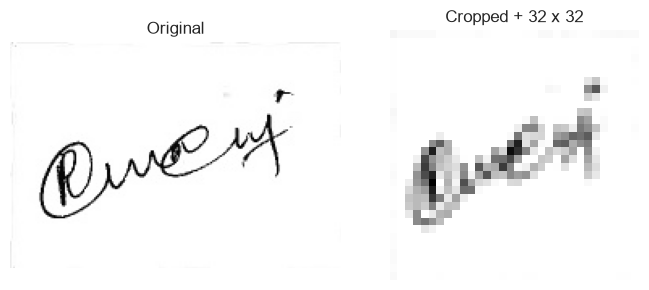

In [4]:
example_original = Image.open(selected_genuine[0]).convert("L")
example_resized = example_original.resize(IMAGE_SIZE)
example_vector = image_to_vector(selected_genuine[0])

print("Original image size      :", example_original.size)
print("Resized image size       :", example_resized.size)
print("Flattened vector length  :", len(example_vector))
print("First 12 vector values   :", np.round(example_vector[:12], 4))

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(example_original)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(example_resized)
axes[1].set_title("Cropped + 32 x 32")
axes[1].axis("off")

plt.tight_layout()
plt.show()


# 8. Exploratory Data Analysis

This EDA section creates:

- sample genuine signatures,
- sample forged signatures,
- class distribution bar chart.


<string>:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


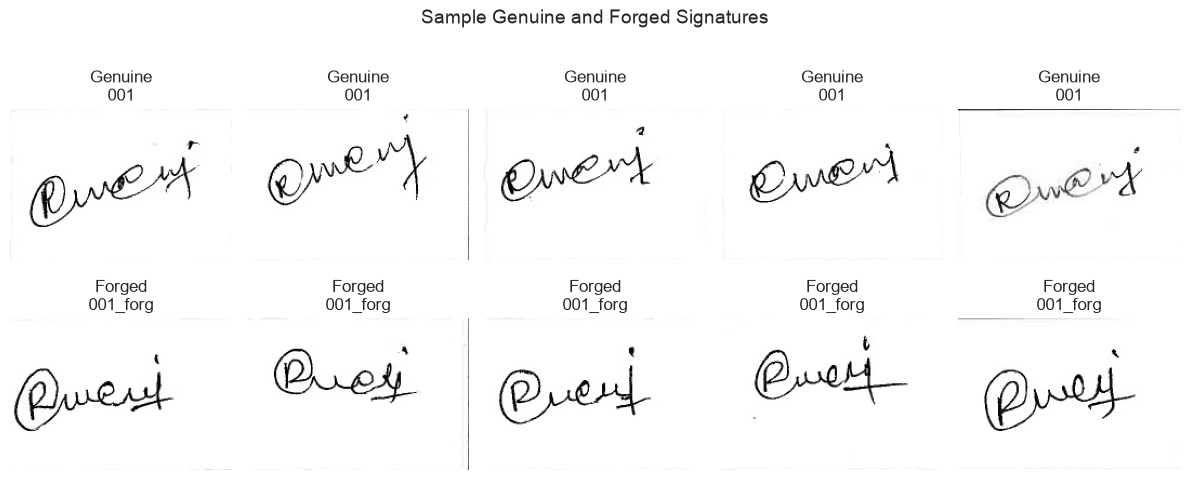

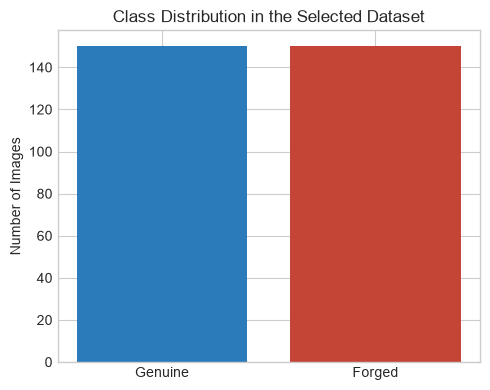

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, path in zip(axes[0], selected_genuine[:5]):
    ax.imshow(Image.open(path).convert("L"))
    ax.set_title(f"Genuine\n{path.parent.name}")
    ax.axis("off")

for ax, path in zip(axes[1], selected_forged[:5]):
    ax.imshow(Image.open(path).convert("L"))
    ax.set_title(f"Forged\n{path.parent.name}")
    ax.axis("off")

plt.suptitle("Sample Genuine and Forged Signatures", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plt.bar(class_distribution.index, class_distribution.values, color=["#2b7bba", "#c44536"])
plt.title("Class Distribution in the Selected Dataset")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()


# 9. Train/Test Split

To prevent leakage, the train/test split is done **before** any scaler or PCA fitting.

Correct workflow:

**raw images -> train/test split -> fit scaler on training only -> fit PCA on training only -> transform train/test -> train classifier -> evaluate**


In [6]:
X_train, X_test, y_train, y_test, train_paths, test_paths = train_test_split(
    X,
    y,
    dataset["paths"],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train distribution:", np.bincount(y_train))
print("y_test distribution :", np.bincount(y_test))


X_train shape: (240, 1024)
X_test shape : (60, 1024)
y_train distribution: [120 120]
y_test distribution : [30 30]


# 10. Baseline Model Without PCA

The baseline uses raw `1024`-dimensional pixel vectors:

**Raw pixels -> StandardScaler -> Logistic Regression**

This baseline helps us judge whether PCA improves or reduces classifier performance.


In [7]:
model_results = []
fitted_models = {}
confusion_matrices = {}
roc_curve_data = {}


def evaluate_pipeline(model_name, pipeline, X_train, X_test, y_train, y_test):
    # Fit a full sklearn pipeline and compute common classification metrics.
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline, "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_score = pipeline.decision_function(X_test)

    pca_step = pipeline.named_steps.get("pca")
    if pca_step is None:
        pca_components = "No PCA"
    else:
        pca_components = int(pca_step.n_components_)

    metrics = {
        "Model": model_name,
        "PCA Components": pca_components,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score),
    }

    fitted_models[model_name] = pipeline
    confusion_matrices[model_name] = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_curve_data[model_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": metrics["ROC-AUC"],
    }

    print(f"Model: {model_name}")
    print("Classification report:")
    print(classification_report(y_test, y_pred, target_names=["Genuine", "Forged"]))
    print("Confusion matrix:")
    print(confusion_matrices[model_name])

    return metrics


baseline_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]
)

baseline_metrics = evaluate_pipeline(
    "Baseline Logistic Regression (No PCA)",
    baseline_pipeline,
    X_train,
    X_test,
    y_train,
    y_test,
)
model_results.append(baseline_metrics)
print("Baseline metrics:")
print(pd.DataFrame([baseline_metrics]).round(4).to_string(index=False))


Model: Baseline Logistic Regression (No PCA)
Classification report:
              precision    recall  f1-score   support

     Genuine       0.77      0.77      0.77        30
      Forged       0.77      0.77      0.77        30

    accuracy                           0.77        60
   macro avg       0.77      0.77      0.77        60
weighted avg       0.77      0.77      0.77        60

Confusion matrix:
[[23  7]
 [ 7 23]]
Baseline metrics:
                                Model PCA Components  Accuracy  Precision  Recall     F1  ROC-AUC
Baseline Logistic Regression (No PCA)         No PCA    0.7667     0.7667  0.7667 0.7667   0.7944


# 11. PCA Preprocessing

PCA must be fitted **only on the training data**.

In this section:

- `StandardScaler` is fitted on `X_train` only,
- PCA is fitted on the scaled training data only,
- the explained variance curve is plotted,
- a 2D PCA visualization using the first two principal components is created.

This section also reports:

- original number of features = `1024`,
- PCA components selected for `95%` explained variance,
- explained variance ratios,
- cumulative explained variance.


Original number of features         : 1024
PCA components for 95% variance     : 138
Total explained variance retained   : 0.9502

Top 10 PCA variance table:
 Component  Explained Variance  Cumulative Variance
         1            0.094006             0.094006
         2            0.082928             0.176933
         3            0.049541             0.226474
         4            0.041987             0.268461
         5            0.036468             0.304929
         6            0.028542             0.333471
         7            0.026844             0.360315
         8            0.025630             0.385946
         9            0.023790             0.409736
        10            0.023020             0.432756


<string>:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:62: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


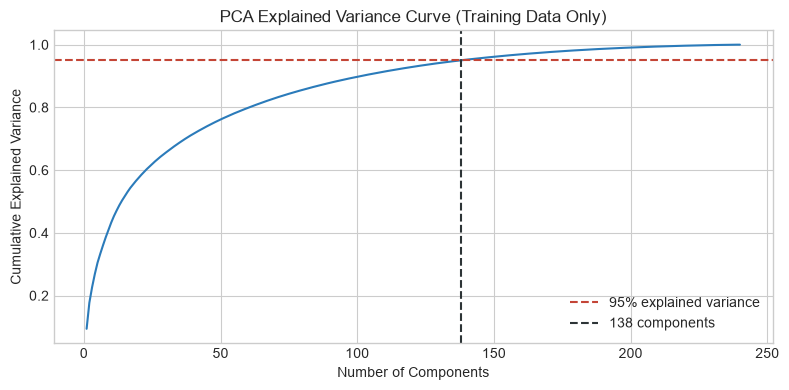

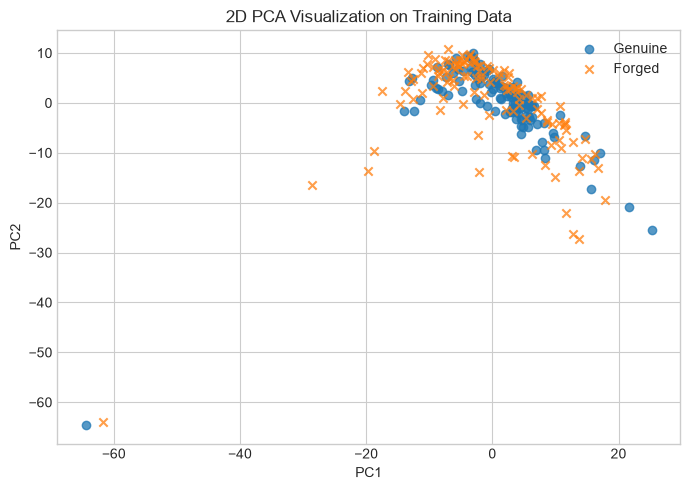

In [8]:
scaler_for_pca = StandardScaler()
X_train_scaled = scaler_for_pca.fit_transform(X_train)
X_test_scaled = scaler_for_pca.transform(X_test)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

pca_95 = PCA(n_components=0.95, random_state=RANDOM_STATE)
pca_95.fit(X_train_scaled)

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca_2d.fit_transform(X_train_scaled)

explained_variance_df = pd.DataFrame(
    {
        "Component": np.arange(1, 11),
        "Explained Variance": pca_full.explained_variance_ratio_[:10],
        "Cumulative Variance": np.cumsum(pca_full.explained_variance_ratio_)[:10],
    }
)

print("Original number of features         :", X_train.shape[1])
print("PCA components for 95% variance     :", pca_95.n_components_)
print("Total explained variance retained   :", round(np.sum(pca_95.explained_variance_ratio_), 4))
print("\nTop 10 PCA variance table:")
print(explained_variance_df.round(6).to_string(index=False))

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
components_for_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance, color="#2b7bba")
plt.axhline(0.95, color="#c44536", linestyle="--", label="95% explained variance")
plt.axvline(components_for_95, color="#2d3436", linestyle="--", label=f"{components_for_95} components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance Curve (Training Data Only)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(
    X_train_2d[y_train == 0, 0],
    X_train_2d[y_train == 0, 1],
    alpha=0.75,
    label="Genuine",
    marker="o",
)
plt.scatter(
    X_train_2d[y_train == 1, 0],
    X_train_2d[y_train == 1, 1],
    alpha=0.75,
    label="Forged",
    marker="x",
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Visualization on Training Data")
plt.legend()
plt.tight_layout()
plt.show()


# 12. Logistic Regression + PCA

Logistic Regression is evaluated under two PCA settings:

- PCA retaining `95%` variance,
- PCA with exactly `50` components.


In [9]:
logistic_pca_95 = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]
)

logistic_pca_50 = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=50, random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]
)

logistic_pca_95_metrics = evaluate_pipeline(
    "Logistic Regression + PCA 95%",
    logistic_pca_95,
    X_train,
    X_test,
    y_train,
    y_test,
)
logistic_pca_50_metrics = evaluate_pipeline(
    "Logistic Regression + PCA 50",
    logistic_pca_50,
    X_train,
    X_test,
    y_train,
    y_test,
)

model_results.extend([logistic_pca_95_metrics, logistic_pca_50_metrics])

print(pd.DataFrame([logistic_pca_95_metrics, logistic_pca_50_metrics]).round(4).to_string(index=False))


Model: Logistic Regression + PCA 95%
Classification report:
              precision    recall  f1-score   support

     Genuine       0.79      0.73      0.76        30
      Forged       0.75      0.80      0.77        30

    accuracy                           0.77        60
   macro avg       0.77      0.77      0.77        60
weighted avg       0.77      0.77      0.77        60

Confusion matrix:
[[22  8]
 [ 6 24]]
Model: Logistic Regression + PCA 50
Classification report:
              precision    recall  f1-score   support

     Genuine       0.78      0.70      0.74        30
      Forged       0.73      0.80      0.76        30

    accuracy                           0.75        60
   macro avg       0.75      0.75      0.75        60
weighted avg       0.75      0.75      0.75        60

Confusion matrix:
[[21  9]
 [ 6 24]]
                        Model  PCA Components  Accuracy  Precision  Recall     F1  ROC-AUC
Logistic Regression + PCA 95%             138    0.7667     0.

# 13. SVM + PCA

The SVM model uses an RBF kernel and is evaluated under the same two PCA settings:

- PCA retaining `95%` variance,
- PCA with exactly `50` components.

For ROC-AUC, the SVM uses `decision_function`.


In [10]:
svm_pca_95 = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
        ("clf", SVC(kernel="rbf", random_state=RANDOM_STATE)),
    ]
)

svm_pca_50 = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=50, random_state=RANDOM_STATE)),
        ("clf", SVC(kernel="rbf", random_state=RANDOM_STATE)),
    ]
)

svm_pca_95_metrics = evaluate_pipeline(
    "SVM RBF + PCA 95%",
    svm_pca_95,
    X_train,
    X_test,
    y_train,
    y_test,
)
svm_pca_50_metrics = evaluate_pipeline(
    "SVM RBF + PCA 50",
    svm_pca_50,
    X_train,
    X_test,
    y_train,
    y_test,
)

model_results.extend([svm_pca_95_metrics, svm_pca_50_metrics])

print(pd.DataFrame([svm_pca_95_metrics, svm_pca_50_metrics]).round(4).to_string(index=False))


Model: SVM RBF + PCA 95%
Classification report:
              precision    recall  f1-score   support

     Genuine       0.70      0.77      0.73        30
      Forged       0.74      0.67      0.70        30

    accuracy                           0.72        60
   macro avg       0.72      0.72      0.72        60
weighted avg       0.72      0.72      0.72        60

Confusion matrix:
[[23  7]
 [10 20]]
Model: SVM RBF + PCA 50
Classification report:
              precision    recall  f1-score   support

     Genuine       0.77      0.77      0.77        30
      Forged       0.77      0.77      0.77        30

    accuracy                           0.77        60
   macro avg       0.77      0.77      0.77        60
weighted avg       0.77      0.77      0.77        60

Confusion matrix:
[[23  7]
 [ 7 23]]
            Model  PCA Components  Accuracy  Precision  Recall     F1  ROC-AUC
SVM RBF + PCA 95%             138    0.7167     0.7407  0.6667 0.7018   0.8311
 SVM RBF + PCA 50  

# 14. Random Forest + PCA

Random Forest is also evaluated after PCA under:

- `95%` explained variance,
- `50` fixed components.


In [11]:
random_forest_pca_95 = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
        ("clf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=1)),
    ]
)

random_forest_pca_50 = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=50, random_state=RANDOM_STATE)),
        ("clf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=1)),
    ]
)

random_forest_pca_95_metrics = evaluate_pipeline(
    "Random Forest + PCA 95%",
    random_forest_pca_95,
    X_train,
    X_test,
    y_train,
    y_test,
)
random_forest_pca_50_metrics = evaluate_pipeline(
    "Random Forest + PCA 50",
    random_forest_pca_50,
    X_train,
    X_test,
    y_train,
    y_test,
)

model_results.extend([random_forest_pca_95_metrics, random_forest_pca_50_metrics])

print(pd.DataFrame([random_forest_pca_95_metrics, random_forest_pca_50_metrics]).round(4).to_string(index=False))


Model: Random Forest + PCA 95%
Classification report:
              precision    recall  f1-score   support

     Genuine       0.72      0.77      0.74        30
      Forged       0.75      0.70      0.72        30

    accuracy                           0.73        60
   macro avg       0.73      0.73      0.73        60
weighted avg       0.73      0.73      0.73        60

Confusion matrix:
[[23  7]
 [ 9 21]]
Model: Random Forest + PCA 50
Classification report:
              precision    recall  f1-score   support

     Genuine       0.83      0.80      0.81        30
      Forged       0.81      0.83      0.82        30

    accuracy                           0.82        60
   macro avg       0.82      0.82      0.82        60
weighted avg       0.82      0.82      0.82        60

Confusion matrix:
[[24  6]
 [ 5 25]]
                  Model  PCA Components  Accuracy  Precision  Recall     F1  ROC-AUC
Random Forest + PCA 95%             138    0.7333     0.7500  0.7000 0.7241   0.

# 15. Confusion Matrices

The following confusion matrices are shown for the three main PCA `95%` models:

- Logistic Regression + PCA
- SVM + PCA
- Random Forest + PCA


<string>:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


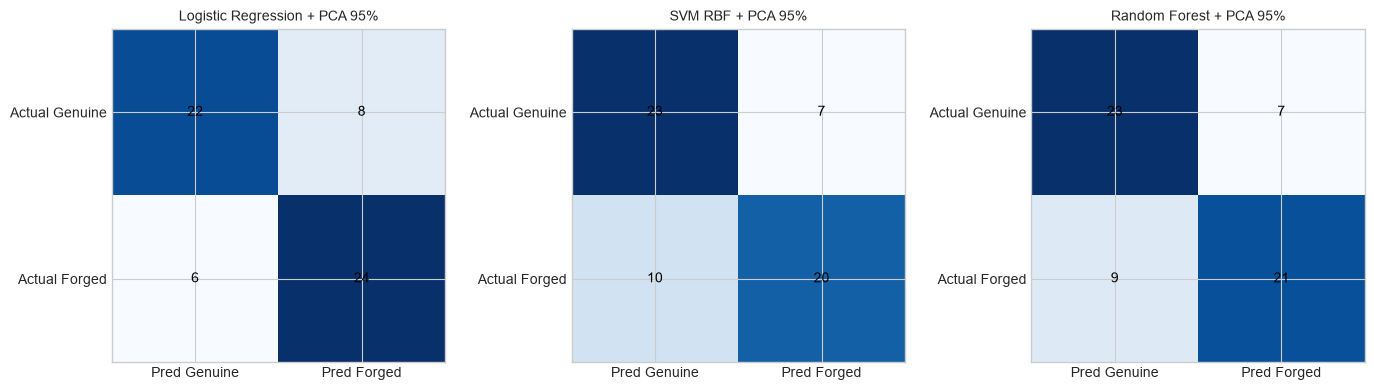

In [12]:
main_confusion_models = [
    "Logistic Regression + PCA 95%",
    "SVM RBF + PCA 95%",
    "Random Forest + PCA 95%",
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, model_name in zip(axes, main_confusion_models):
    cm = confusion_matrices[model_name]
    image = ax.imshow(cm, cmap="Blues")
    ax.set_title(model_name, fontsize=10)
    ax.set_xticks([0, 1], labels=["Pred Genuine", "Pred Forged"])
    ax.set_yticks([0, 1], labels=["Actual Genuine", "Actual Forged"])

    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            ax.text(col, row, cm[row, col], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()


# 16. ROC Curves

One combined ROC curve is created for the three main PCA `95%` models.  
AUC values are shown in the legend.


<string>:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


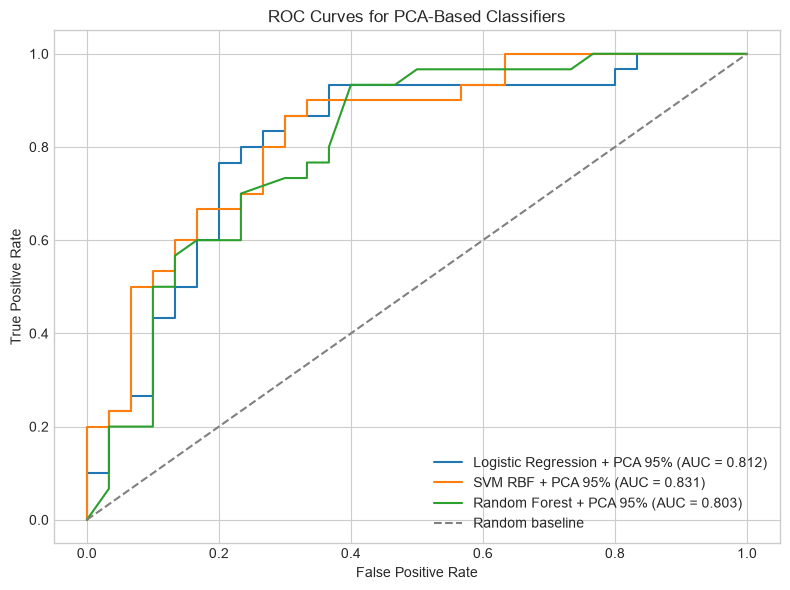

In [13]:
plt.figure(figsize=(8, 6))

for model_name in main_confusion_models:
    roc_info = roc_curve_data[model_name]
    plt.plot(
        roc_info["fpr"],
        roc_info["tpr"],
        label=f"{model_name} (AUC = {roc_info['auc']:.3f})",
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for PCA-Based Classifiers")
plt.legend()
plt.tight_layout()
plt.show()


# 17. Model Comparison

This section creates:

- a results table with Accuracy, Precision, Recall, F1, and ROC-AUC,
- a bar chart comparing Accuracy and F1-score across all evaluated models.


Model comparison table:
                                Model PCA Components  Accuracy  Precision  Recall     F1  ROC-AUC
               Random Forest + PCA 50             50    0.8167     0.8065  0.8333 0.8197   0.8822
        Logistic Regression + PCA 95%            138    0.7667     0.7500  0.8000 0.7742   0.8122
                     SVM RBF + PCA 50             50    0.7667     0.7667  0.7667 0.7667   0.8211
Baseline Logistic Regression (No PCA)         No PCA    0.7667     0.7667  0.7667 0.7667   0.7944
         Logistic Regression + PCA 50             50    0.7500     0.7273  0.8000 0.7619   0.7533
              Random Forest + PCA 95%            138    0.7333     0.7500  0.7000 0.7241   0.8028
                    SVM RBF + PCA 95%            138    0.7167     0.7407  0.6667 0.7018   0.8311


<string>:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


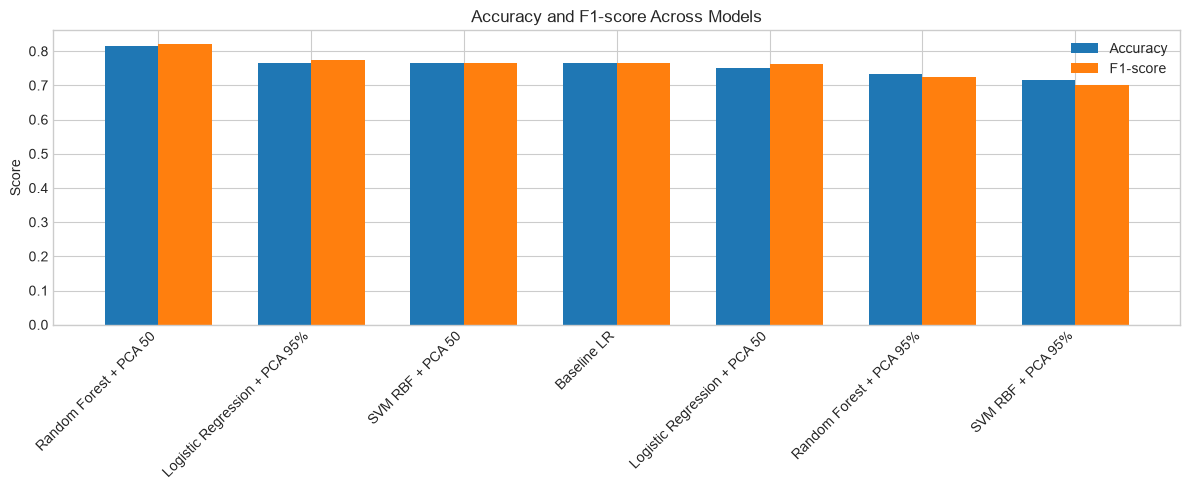

In [14]:
results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values(by=["F1", "ROC-AUC"], ascending=False).reset_index(drop=True)

print("Model comparison table:")
print(results_df.round(4).to_string(index=False))

comparison_df = results_df.copy()
comparison_df["Display Label"] = comparison_df["Model"].str.replace("Baseline Logistic Regression (No PCA)", "Baseline LR", regex=False)

x_positions = np.arange(len(comparison_df))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x_positions - width / 2, comparison_df["Accuracy"], width=width, label="Accuracy")
plt.bar(x_positions + width / 2, comparison_df["F1"], width=width, label="F1-score")
plt.xticks(x_positions, comparison_df["Display Label"], rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Accuracy and F1-score Across Models")
plt.legend()
plt.tight_layout()
plt.show()


# 18. SVM Hyperparameter Tuning

A small `GridSearchCV` is applied only to SVM, as requested.

Grid:

- `C = [0.1, 1, 10]`
- `gamma = ['scale', 'auto']`
- `cv = 5`
- `scoring = 'f1'`


In [15]:
svm_tuning_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
        ("clf", SVC(kernel="rbf", random_state=RANDOM_STATE)),
    ]
)

svm_param_grid = {
    "clf__C": [0.1, 1, 10],
    "clf__gamma": ["scale", "auto"],
}

svm_grid_search = GridSearchCV(
    estimator=svm_tuning_pipeline,
    param_grid=svm_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=1,
)

svm_grid_search.fit(X_train, y_train)

best_svm = svm_grid_search.best_estimator_
y_pred_best_svm = best_svm.predict(X_test)
y_score_best_svm = best_svm.decision_function(X_test)

best_svm_metrics = {
    "Model": "Tuned SVM RBF + PCA 95%",
    "PCA Components": int(best_svm.named_steps["pca"].n_components_),
    "Accuracy": accuracy_score(y_test, y_pred_best_svm),
    "Precision": precision_score(y_test, y_pred_best_svm),
    "Recall": recall_score(y_test, y_pred_best_svm),
    "F1": f1_score(y_test, y_pred_best_svm),
    "ROC-AUC": roc_auc_score(y_test, y_score_best_svm),
}

fitted_models["Tuned SVM RBF + PCA 95%"] = best_svm
confusion_matrices["Tuned SVM RBF + PCA 95%"] = confusion_matrix(y_test, y_pred_best_svm)
fpr_best_svm, tpr_best_svm, _ = roc_curve(y_test, y_score_best_svm)
roc_curve_data["Tuned SVM RBF + PCA 95%"] = {
    "fpr": fpr_best_svm,
    "tpr": tpr_best_svm,
    "auc": best_svm_metrics["ROC-AUC"],
}

model_results.append(best_svm_metrics)
results_df = pd.DataFrame(model_results).sort_values(by=["F1", "ROC-AUC"], ascending=False).reset_index(drop=True)

print("Best SVM parameters:", svm_grid_search.best_params_)
print("Best cross-validation F1:", round(svm_grid_search.best_score_, 4))
print("\nBest SVM test metrics:")
print(pd.DataFrame([best_svm_metrics]).round(4).to_string(index=False))


Best SVM parameters: {'clf__C': 0.1, 'clf__gamma': 'auto'}
Best cross-validation F1: 0.743

Best SVM test metrics:
                  Model  PCA Components  Accuracy  Precision  Recall    F1  ROC-AUC
Tuned SVM RBF + PCA 95%             138    0.6167     0.5686  0.9667 0.716   0.7844


# 19. PCA Component Comparison

To isolate the effect of PCA dimensionality while keeping the classifier fixed, this section compares the **Random Forest** classifier under:

- PCA retaining `95%` variance,
- PCA with exactly `50` components.

This creates the requested table:

**PCA Setting | Components | Accuracy | F1 | ROC-AUC**


In [16]:
rf_component_comparison = results_df[
    results_df["Model"].isin(["Random Forest + PCA 95%", "Random Forest + PCA 50"])
][["Model", "PCA Components", "Accuracy", "F1", "ROC-AUC"]].copy()

rf_component_comparison["PCA Setting"] = rf_component_comparison["Model"].map(
    {
        "Random Forest + PCA 95%": "95% variance",
        "Random Forest + PCA 50": "50 components",
    }
)

rf_component_comparison = rf_component_comparison[
    ["PCA Setting", "PCA Components", "Accuracy", "F1", "ROC-AUC"]
].sort_values(by="PCA Components")

print("PCA component comparison table:")
print(rf_component_comparison.round(4).to_string(index=False))


PCA component comparison table:
  PCA Setting PCA Components  Accuracy     F1  ROC-AUC
50 components             50    0.8167 0.8197   0.8822
 95% variance            138    0.7333 0.7241   0.8028


# 20. Manual PCA vs sklearn PCA

This section connects the machine learning implementation to the earlier linear algebra project.

Manual method:

- covariance matrix -> eigenvalues/eigenvectors -> principal directions

ML implementation:

- `StandardScaler` -> `sklearn PCA` -> principal components -> classifier

The goal here is not to match eigenvector signs exactly, because eigenvectors may differ by sign.  
Instead, we compare whether the **principal variance structure** is consistent.


In [17]:
manual_covariance_matrix = np.cov(X_train_scaled, rowvar=False)
manual_eigenvalues, manual_eigenvectors = np.linalg.eigh(manual_covariance_matrix)
manual_eigenvalues = manual_eigenvalues[::-1]
manual_explained_variance_ratio = manual_eigenvalues / np.sum(manual_eigenvalues)

pca_comparison_df = pd.DataFrame(
    {
        "Component": np.arange(1, 11),
        "Manual EVR": manual_explained_variance_ratio[:10],
        "sklearn EVR": pca_full.explained_variance_ratio_[:10],
    }
)
pca_comparison_df["Absolute Difference"] = (
    pca_comparison_df["Manual EVR"] - pca_comparison_df["sklearn EVR"]
).abs()

print("Manual PCA vs sklearn PCA variance comparison:")
print(pca_comparison_df.round(8).to_string(index=False))
print("\nThe matching explained variance ratios show that the principal variance structure is consistent.")
print("Eigenvector signs need not match exactly because eigenvectors are sign-ambiguous.")


Manual PCA vs sklearn PCA variance comparison:
 Component  Manual EVR  sklearn EVR  Absolute Difference
         1    0.094006     0.094006                  0.0
         2    0.082928     0.082928                  0.0
         3    0.049541     0.049541                  0.0
         4    0.041987     0.041987                  0.0
         5    0.036468     0.036468                  0.0
         6    0.028542     0.028542                  0.0
         7    0.026844     0.026844                  0.0
         8    0.025630     0.025630                  0.0
         9    0.023790     0.023790                  0.0
        10    0.023020     0.023020                  0.0

The matching explained variance ratios show that the principal variance structure is consistent.
Eigenvector signs need not match exactly because eigenvectors are sign-ambiguous.


# 21. Results Discussion

This section highlights the best-performing model and contrasts:

- unsupervised PCA anomaly detection from the earlier project,
- supervised PCA + classifier learning from the present project.


In [18]:
best_model_row = results_df.sort_values(by=["F1", "ROC-AUC"], ascending=False).iloc[0]
baseline_row = results_df[results_df["Model"] == "Baseline Logistic Regression (No PCA)"].iloc[0]
logistic_pca_row = results_df[results_df["Model"] == "Logistic Regression + PCA 95%"].iloc[0]

best_model_display = best_model_row.copy()
for metric_name in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    best_model_display[metric_name] = round(float(best_model_display[metric_name]), 4)

print("Best model based primarily on F1-score and ROC-AUC:")
print(best_model_display.to_string())

print("\nInterpretation:")
print(
    f"- Baseline Logistic Regression without PCA achieved F1 = {baseline_row['F1']:.4f} "
    f"and ROC-AUC = {baseline_row['ROC-AUC']:.4f}."
)
print(
    f"- Logistic Regression with PCA 95% achieved F1 = {logistic_pca_row['F1']:.4f} "
    f"and ROC-AUC = {logistic_pca_row['ROC-AUC']:.4f}."
)
if logistic_pca_row["F1"] > baseline_row["F1"]:
    print(
        "- In this dataset subset, PCA slightly improved Logistic Regression over the raw-pixel baseline."
    )
elif logistic_pca_row["F1"] < baseline_row["F1"]:
    print(
        "- In this dataset subset, PCA reduced Logistic Regression performance relative to the raw-pixel baseline."
    )
else:
    print(
        "- In this dataset subset, PCA and the raw-pixel baseline gave nearly identical Logistic Regression performance."
    )
print(
    "- The earlier linear algebra notebook used PCA plus reconstruction error as an unsupervised anomaly detector."
)
print(
    "- This machine learning notebook uses PCA as a feature-reduction step before supervised classifiers that directly optimize class separation."
)


Best model based primarily on F1-score and ROC-AUC:
Model             Random Forest + PCA 50
PCA Components                        50
Accuracy                          0.8167
Precision                         0.8065
Recall                            0.8333
F1                                0.8197
ROC-AUC                           0.8822

Interpretation:
- Baseline Logistic Regression without PCA achieved F1 = 0.7667 and ROC-AUC = 0.7944.
- Logistic Regression with PCA 95% achieved F1 = 0.7742 and ROC-AUC = 0.8122.
- In this dataset subset, PCA slightly improved Logistic Regression over the raw-pixel baseline.
- The earlier linear algebra notebook used PCA plus reconstruction error as an unsupervised anomaly detector.
- This machine learning notebook uses PCA as a feature-reduction step before supervised classifiers that directly optimize class separation.


# 22. Limitations

- Only `300` images were used in this mini-project.
- The subset is balanced and reproducible, but still small compared with the full dataset.
- Results depend on the chosen image resolution (`32 x 32`), subset size, PCA setting, and classifier.
- PCA is unsupervised, so it may preserve variance that is not necessarily the most discriminative for classification.
- This project is an academic proof-of-concept, not a forensic-grade signature authentication system.


# 23. Conclusion

This notebook shows that PCA can reduce high-dimensional signature images into a more compact feature space before machine learning classification.  
The final summary below prints the dataset statistics, PCA dimensionality, best model, and best tuned SVM information.


In [19]:
best_model_row = results_df.sort_values(by=["F1", "ROC-AUC"], ascending=False).iloc[0]

print("FINAL PROJECT SUMMARY")
print("=" * 60)
print("Dataset:")
print("Total samples        :", len(y))
print("Genuine count        :", int(np.sum(y == 0)))
print("Forged count         :", int(np.sum(y == 1)))
print("Original dimensions  :", X.shape[1])

print("\nPCA:")
print("95% variance components :", pca_95.n_components_)
print("Explained variance      :", round(np.sum(pca_95.explained_variance_ratio_), 4))

print("\nBest model:")
print("Model name  :", best_model_row["Model"])
print("Accuracy    :", round(best_model_row["Accuracy"], 4))
print("Precision   :", round(best_model_row["Precision"], 4))
print("Recall      :", round(best_model_row["Recall"], 4))
print("F1-score    :", round(best_model_row["F1"], 4))
print("ROC-AUC     :", round(best_model_row["ROC-AUC"], 4))

print("\nBest SVM:")
print("Best hyperparameters :", svm_grid_search.best_params_)
print("CV F1-score          :", round(svm_grid_search.best_score_, 4))
print("Test F1-score        :", round(best_svm_metrics["F1"], 4))


FINAL PROJECT SUMMARY
Dataset:
Total samples        : 300
Genuine count        : 150
Forged count         : 150
Original dimensions  : 1024

PCA:
95% variance components : 138
Explained variance      : 0.9502

Best model:
Model name  : Random Forest + PCA 50
Accuracy    : 0.8167
Precision   : 0.8065
Recall      : 0.8333
F1-score    : 0.8197
ROC-AUC     : 0.8822

Best SVM:
Best hyperparameters : {'clf__C': 0.1, 'clf__gamma': 'auto'}
CV F1-score          : 0.743
Test F1-score        : 0.716
